# MaleCNS: Hidden Excursions and Future Information

## Context & Methods
One MaleCNS v1.0 graph, all raw contact weights retained. The supplied walk
normalizes by every outgoing contact. All active source IDs remain separate.
Post-only IDs are absorbing by model choice and are compressed only within
their observed category. Model steps are not physical time.

### Key Assumptions
For each of all 27 assigned-neuron superclasses, compare uniform sources with
out-weight-proportional sources. Both have the same initial superclass
observation. Their mixture coordinate alpha is evaluated at 1/2.
This is a designed structural contrast, not a measured neural state or history.

Two hidden spaces must not be conflated: the initial contrast is within an
assigned superclass; first excursions pass through nonassigned raw IDs.
Fisher changes are not attributed causally to those nonassigned excursions.
The coarse 30-category observation also hides active versus absorbed status.

## Data
Official source: https://male-cns.janelia.org/download/ ; v1.0 minconf-0.5.
Inputs, exact code hashes, cache hashes and environment are in
`verify/MaleCNS/hidden_walk_information_result.json`.
This notebook reads completed summaries and checks their cache hashes.


In [1]:
import hashlib, json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'verify/MaleCNS/hidden_walk_information_result.json').exists())
folder = root/'verify/MaleCNS'
result = json.loads((folder/'hidden_walk_information_result.json').read_text(encoding='utf-8'))
def digest(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()
assert digest(folder/'hidden_walk_information.py') == result['source_code_sha256']
assert digest(root/'tests/test_malecns_hidden_walk.py') == result['test_code_sha256']
assert digest(result['dyad_result']) == result['dyad_result_sha256']
for artifact in result['artifacts'].values():
    assert Path(artifact['path']).stat().st_size == artifact['bytes']
    assert digest(artifact['path']) == artifact['sha256']
with np.load(result['artifacts']['probe_traces.npz']['path']) as cache:
    observed = cache['category_observation']
    returns = cache['first_return_by_target']
    middle_step2 = cache['first_return_step2_by_initial_middle']
    names = cache['source_categories'].tolist()
rows = result['cohorts']
assert names == [r['category'] for r in rows] and len(rows) == 27
fisher = np.array([[t['category_fisher'] for t in r['trajectory']] for r in rows])
refined = np.array([[t['active_id_terminal_category_fisher'] for t in r['trajectory']] for r in rows])
tv = np.array([[t['category_total_variation'] for t in r['trajectory']] for r in rows])
assert np.all(fisher <= refined + 5e-10) and np.all(np.diff(refined, axis=1) <= 5e-10)
assert np.all(fisher[:, 0] < 5e-10)
np.testing.assert_allclose(observed.sum(axis=-1), 1, atol=5e-10, rtol=0)
np.testing.assert_allclose(middle_step2.sum(axis=1), returns[:, 0], atol=5e-10, rtol=0)
for i, row in enumerate(rows):
    cumulative = returns[i].sum(axis=(0, 2))
    np.testing.assert_allclose(cumulative, row['first_excursion']['steps'][-1]['cumulative_return_probability'], atol=5e-10, rtol=0)
figures = folder/'figures/hidden-walk-checked'
figures.mkdir(parents=True)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('All input hashes and summary invariants passed.')
print('Above numerical tolerance at a future step:', int(np.count_nonzero(fisher[:, 1:].max(axis=1) > 5e-10)), '/ 27 categories')
print('Analysis environment:', result['software'])


All input hashes and summary invariants passed.
Above numerical tolerance at a future step: 27 / 27 categories
Analysis environment: {'python': '3.11.15', 'executable': 'C:\\Users\\dongh\\AppData\\Local\\uv\\cache\\archive-v0\\Sp2cxzBGA63aECqn\\Scripts\\python.exe', 'numpy': '2.4.6', 'scipy': '1.17.1'}


## Results
### 1. First return after entering a hidden segment
Each point is cumulative return on steps 2..64 as a fraction of initial
probability, not conditional on entering the hidden set. Returns include active
and post-only assigned-neuron targets. Once returned, a path is removed from
this first-excursion calculation. Lines extend to cumulative return plus the
remaining active hidden mass, an upper bound on later return, not a confidence
interval. Direct assigned arrivals on step 1 are excluded from these points.


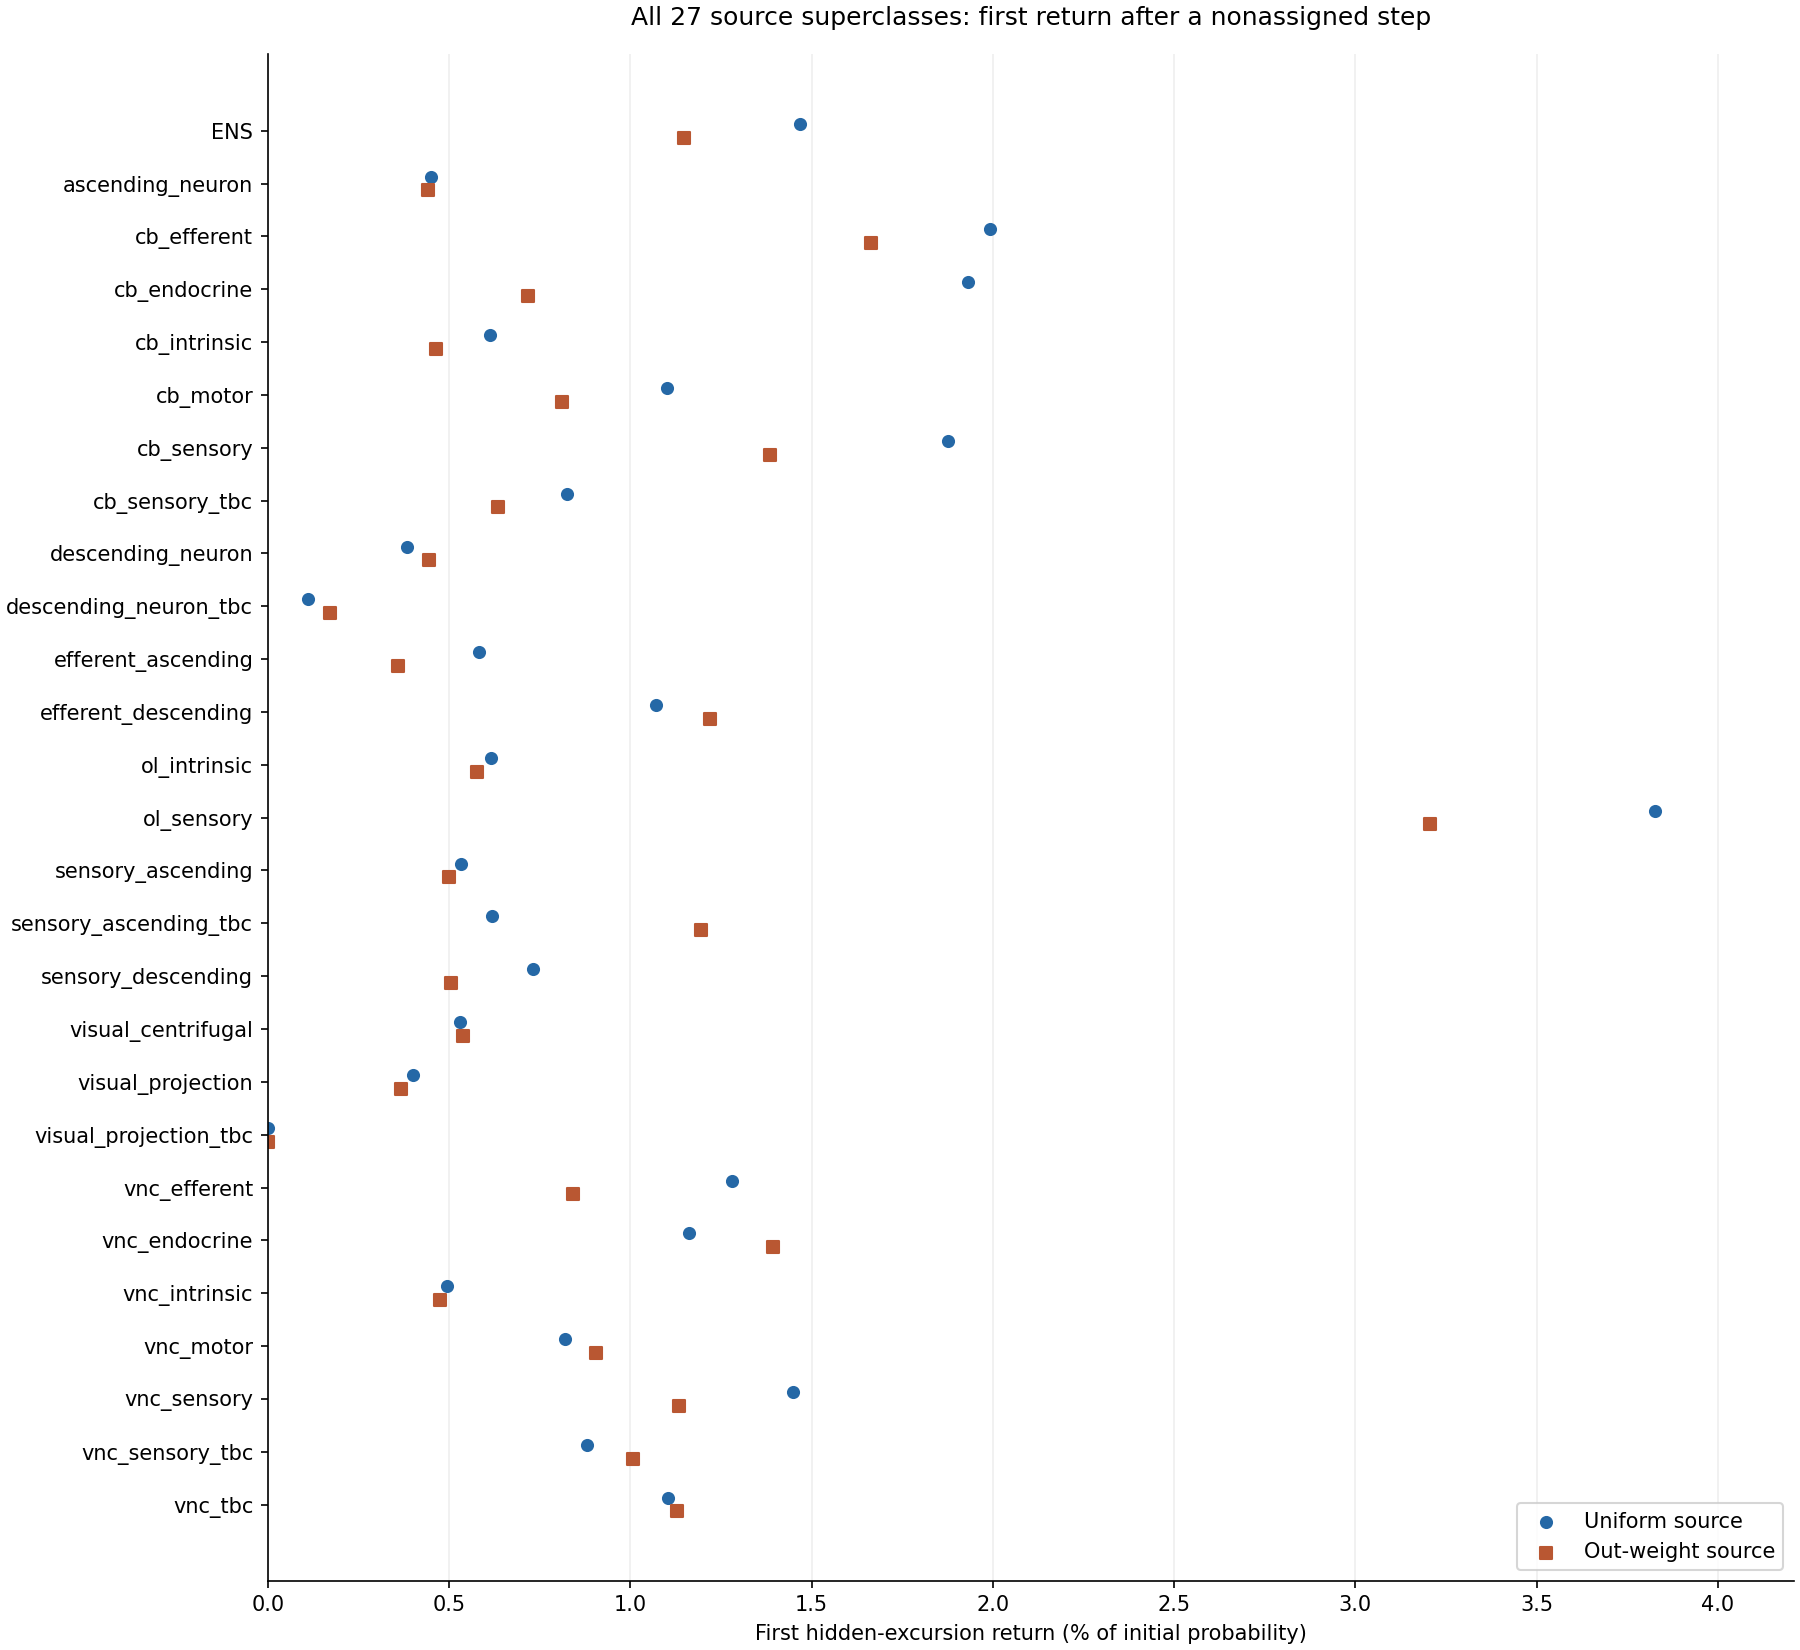

Largest unresolved active hidden probability at step 64: 1.9444420320909976e-08
Largest cumulative return, uniform / out-weight: [0.03826487 0.03205549]


In [2]:
last = [r['first_excursion']['steps'][-1] for r in rows]
cumulative = np.array([r['cumulative_return_probability'] for r in last])
tail = np.array([r['unresolved_active_hidden_probability'] for r in last])
fig, ax = plt.subplots(figsize=(12, 11), layout='constrained')
for probe, shift, color, marker, label in [(0, -.13, '#2568a6', 'o', 'Uniform source'), (1, .13, '#b95732', 's', 'Out-weight source')]:
    y = np.arange(27) + shift
    ax.scatter(100*cumulative[:, probe], y, color=color, marker=marker, label=label, s=28)
    ax.hlines(y, 100*cumulative[:, probe], 100*(cumulative[:, probe]+tail[:, probe]), color=color, linewidth=2)
ax.set_yticks(range(27), names)
ax.invert_yaxis()
ax.set_xlim(0, max(1, float(100*(cumulative+tail).max())*1.1))
ax.set_xlabel('First hidden-excursion return (% of initial probability)')
ax.set_title('All 27 source superclasses: first return after a nonassigned step', pad=14)
ax.grid(axis='x', alpha=.2)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
path = figures/'first_hidden_return.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))
print('Largest unresolved active hidden probability at step 64:', tail.max())
print('Largest cumulative return, uniform / out-weight:', cumulative.max(axis=0))


### 2. A coordinate hidden at the initial observation
The heatmap is the scalar Fisher information about the same mixture coordinate
at each separate observation time. It is not joint information from a whole
trajectory. Grey means at or below 5e-10, the numerical comparison tolerance,
not a statistical significance threshold. No epsilon or regularizer is added
to the Fisher calculation. Colour uses a logarithmic scale.


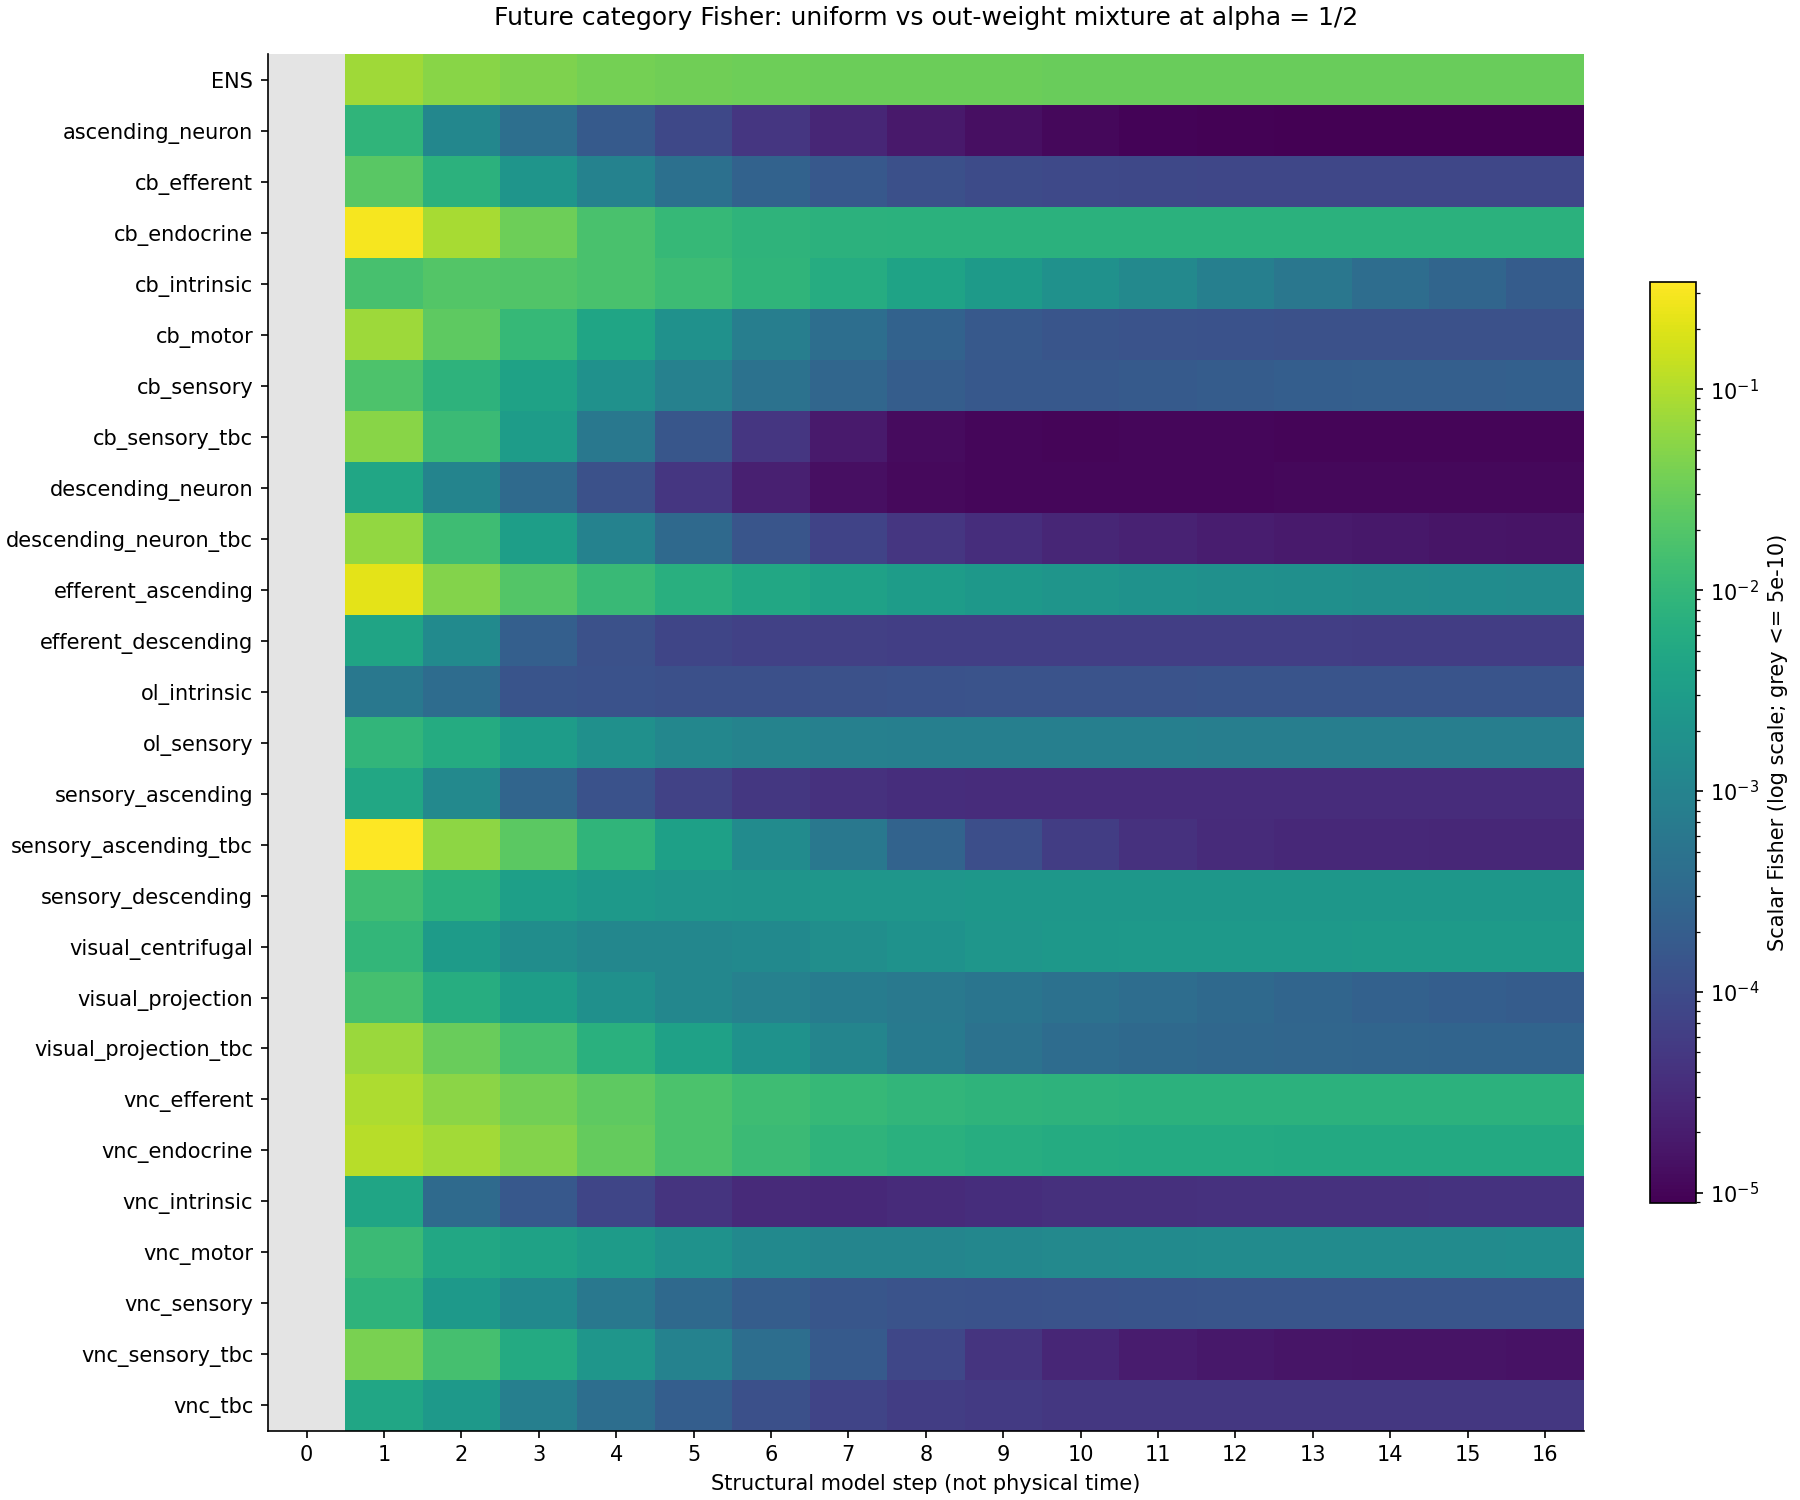

ENS: peak=0.074806956, peak step=1, step16=0.031100134
ascending_neuron: peak=0.0087158265, peak step=1, step16=8.891601e-06
cb_efferent: peak=0.023306219, peak step=1, step16=8.3619875e-05
cb_endocrine: peak=0.29243717, peak step=1, step16=0.0074017668
cb_intrinsic: peak=0.019918469, peak step=2, step16=0.00019169866
cb_motor: peak=0.073473812, peak step=1, step16=0.00012198153
cb_sensory: peak=0.01757687, peak step=1, step16=0.00022280203
cb_sensory_tbc: peak=0.051442792, peak step=1, step16=1.0153934e-05
descending_neuron: peak=0.0045054734, peak step=1, step16=1.110018e-05
descending_neuron_tbc: peak=0.060641897, peak step=1, step16=1.5614906e-05
efferent_ascending: peak=0.21711177, peak step=1, step16=0.0014707786
efferent_descending: peak=0.0041866394, peak step=1, step16=6.1489162e-05
ol_intrinsic: peak=0.00060991342, peak step=1, step16=0.00013612779
ol_sensory: peak=0.0092118065, peak step=1, step16=0.00081719622
sensory_ascending: peak=0.004988239, peak step=1, step16=3.41002

In [3]:
fig, ax = plt.subplots(figsize=(12, 10), layout='constrained')
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('#e4e4e4')
visible = np.ma.masked_less_equal(fisher, 5e-10)
positive = fisher[fisher > 5e-10]
norm = LogNorm(vmin=float(positive.min()) if len(positive) else 5e-10, vmax=max(float(fisher.max()), 1e-9))
im = ax.imshow(visible, aspect='auto', interpolation='nearest', cmap=cmap, norm=norm)
ax.set_yticks(range(27), names)
ax.set_xticks(range(result['steps']+1))
ax.set_xlabel('Structural model step (not physical time)')
ax.set_title('Future category Fisher: uniform vs out-weight mixture at alpha = 1/2', pad=14)
fig.colorbar(im, ax=ax, fraction=.035, label='Scalar Fisher (log scale; grey <= 5e-10)')
path = figures/'future_category_fisher.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))
for name, row in zip(names, fisher):
    print(f'{name}: peak={row.max():.8g}, peak step={int(row.argmax())}, step16={row[-1]:.8g}')


### 3. Exposure is not information creation
These six categories were chosen for structural coverage, not for winning
results. Blue resolves active IDs and terminal category; orange resolves only
30 identity categories. The former also retains active/absorbed status.
Refined information cannot increase through this fixed Markov walk; coarser
future observations can expose an initially hidden coordinate without creating
information. All 27 categories remain in the preceding figure and saved table.


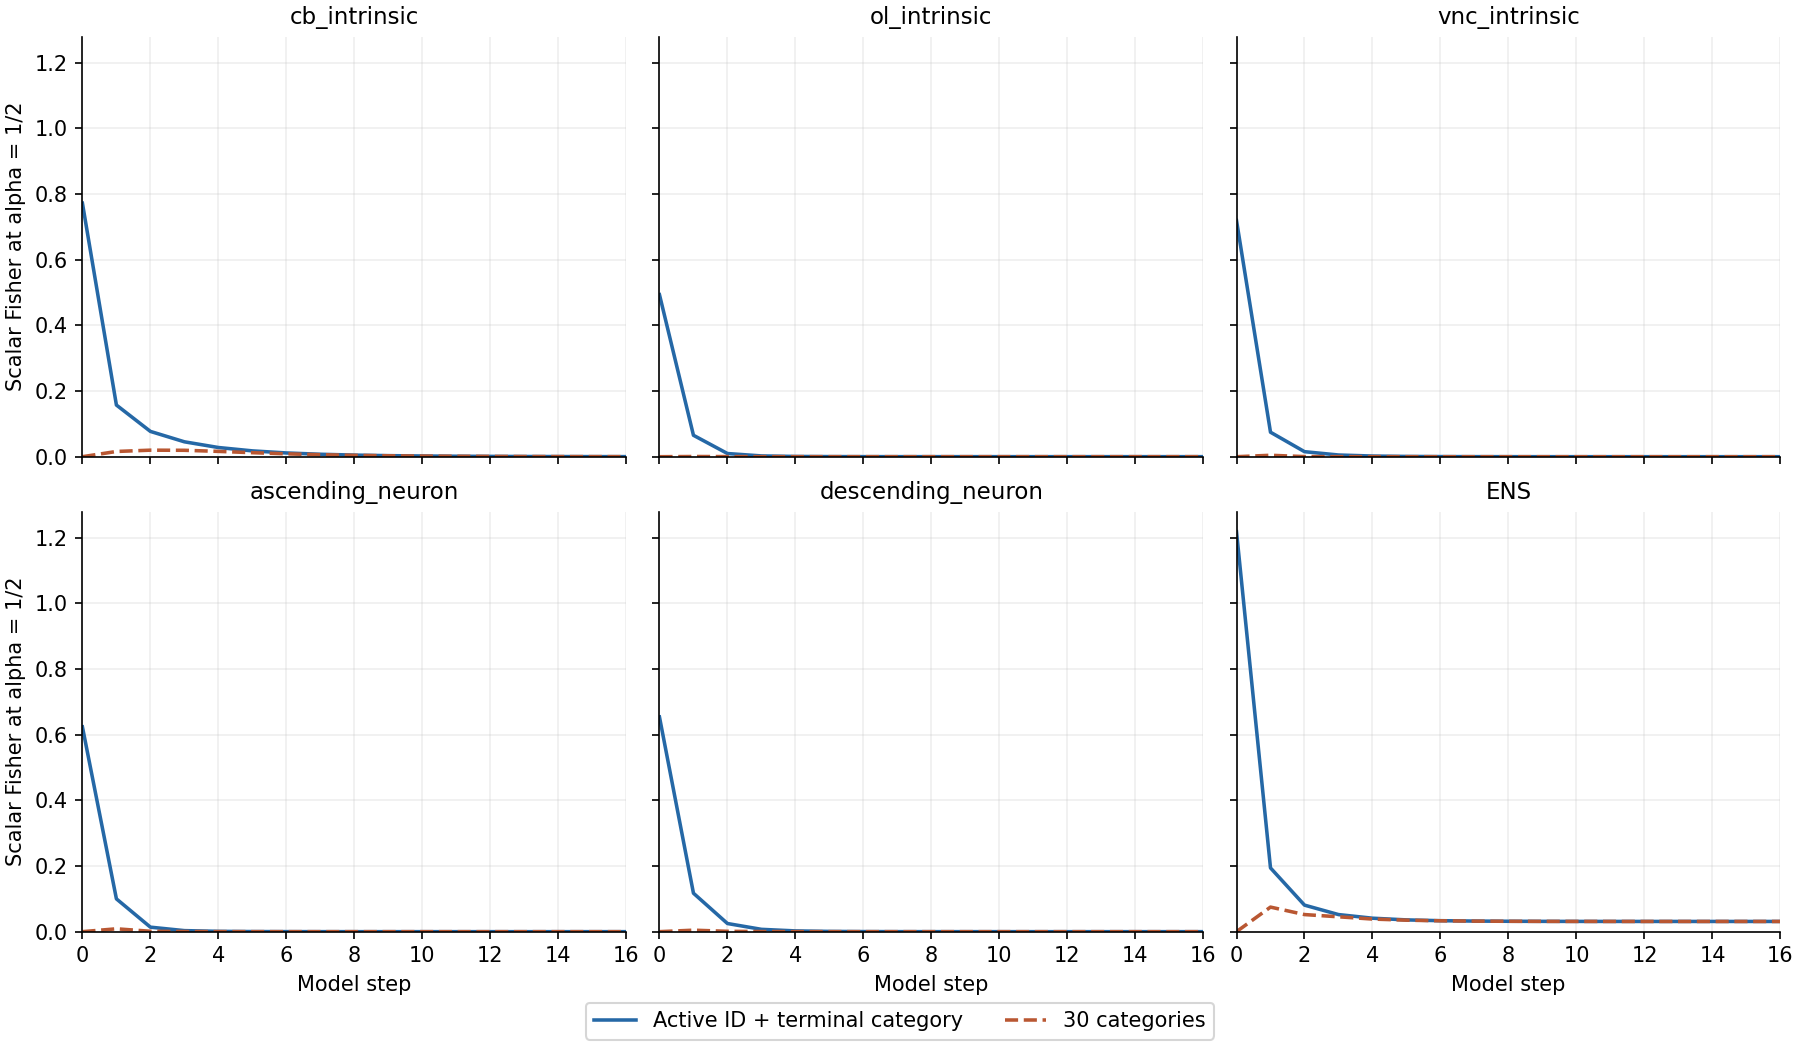

In [4]:
selected = ['cb_intrinsic', 'ol_intrinsic', 'vnc_intrinsic', 'ascending_neuron', 'descending_neuron', 'ENS']
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True, layout='constrained')
for ax, name in zip(axes.flat, selected):
    i = names.index(name)
    ax.plot(range(result['steps']+1), refined[i], color='#2568a6', label='Active ID + terminal category', linewidth=1.7)
    ax.plot(range(result['steps']+1), fisher[i], color='#b95732', linestyle='--', label='30 categories', linewidth=1.7)
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=.2)
    ax.set_xlim(0, result['steps'])
upper = 1.05 * max(float(refined[names.index(name)].max()) for name in selected)
axes[0, 0].set_ylim(0, upper)
assert all(np.all((line.get_ydata() >= 0) & (line.get_ydata() <= upper))
           for ax in axes.flat for line in ax.lines)
for ax in axes[-1]:
    ax.set_xlabel('Model step')
for ax in axes[:, 0]:
    ax.set_ylabel('Scalar Fisher at alpha = 1/2')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='outside lower center', ncol=2, fontsize=10)
path = figures/'refined_and_category_information.png'
fig.savefig(path, dpi=150)
plt.close(fig)
display(Image(filename=str(path), width=1000))


## Takeaways and Limits
Results are properties of the raw-contact-supported, absorbing proxy model.
The source mixture is an internal composition contrast, not measured learning.
One scalar Fisher does not reconstruct a full Riemannian metric or prove
curvature, neural coding, biological memory, or fractality.

The first hidden-excursion calculation and the superclass-observation contrast
use different hidden spaces. Their coexistence is not a causal attribution.
A 60-output control retaining active versus absorbed status, a memoryless
coarse predictor, controlled hidden-state perturbations, alternative boundary
models, ROI and biological sign/time calibration remain separate next tests.

Methods and exact limits: `ledger/malecns_hidden_walk_findings.md`.
